# Project Overview

This project analyzes marketing campaign performance to identify key drivers of profitability and optimize campaign strategy. Using campaign-level data, the analysis explores relationships between engagement metrics (CTR, CPC, impressions), customer segments, and financial outcomes such as profit and ROI.
The workflow combines exploratory data analysis, feature engineering, and machine learning techniques. Linear Regression is used to quantify the impact of campaign attributes on profit, while KMeans clustering is applied to segment campaigns into distinct performance groups.

The goal is to move beyond descriptive insights and provide data-driven recommendations that improve campaign efficiency, reduce acquisition costs, and maximize overall profitability.

# Project Objectives
The primary objectives of this project are:

1. Analyze marketing campaign performance across channels and customer segments
2. Identify key factors influencing profitability (CTR, CPC, engagement, etc.)
3. Evaluate the relationship between ROI and profit to determine the most reliable performance metric
4. Build a predictive model to estimate campaign profitability
5. Segment campaigns using clustering to uncover distinct performance groups

# Data Description

The dataset consists of campaign-level marketing data, including performance, financial, and engagement metrics. Key features include:

- Performance metrics: clicks, impressions, CTR (click-through rate), CPC (cost per click)
- Financial metrics: revenue, profit, ROI
- Engagement metric: engagement score
- Categorical variables: campaign type, channel used, customer segment

### Install Required Packages

In [1]:
!pip install psycopg2-binary
!pip install sqlalchemy
!pip install python-dotenv

### Import Required Libraries

In [2]:
import os
import warnings
from urllib.parse import quote_plus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualization settings
sns.set_style('whitegrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (10,6)

warnings.filterwarnings('ignore')

### Load Environment & Connect to PostgreSQL

In [3]:
# Load environment variables for secure DB access
load_dotenv()

db_user = os.getenv('DB_USER')
db_pass = quote_plus(os.getenv('DB_PASS'))
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

In [4]:
# Create SQLAlchemy engine
engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")

### Load Data

In [5]:
# Load main table
df = pd.read_sql('SELECT * FROM campaign;', engine)

df.head(3)

,campaign_id,company,campaign_type,target_audience,duration,channel_used,conversion_rate,acquisition_cost,roi,location,language,clicks,impressions,engagement_score,customer_segment,date,ctr,cpc,month
0,45924,TechCorp,Display,Men 18-24,15,Facebook,0.05,15244.0,5.34,Chicago,Spanish,807,1080,10,Foodies,2021-10-26,0.75,18.89,2021-10-01
1,46085,NexGen Systems,Email,Women 35-44,15,Email,0.10,11767.0,7.98,Miami,French,548,5658,4,Foodies,2021-04-05,0.10,21.47,2021-04-01
2,46507,NexGen Systems,Search,Women 25-34,45,Website,0.10,13018.0,5.98,Houston,Mandarin,777,5138,8,Foodies,2021-06-01,0.15,16.75,2021-06-01


In [6]:
# Load ML ready table for modeling
ml_df = pd.read_sql('SELECT * FROM campaign_features_ml;', engine)

ml_df.head(3)

,campaign_type,channel_used,customer_segment,month,clicks,impressions,ctr,cpc,conversion_rate,engagement_score,revenue,profit,roi
0,Display,Facebook,Foodies,2021-10-01,807,1080,0.75,18.89,0.05,10,40350.0,25106.0,164.694306
1,Email,Email,Foodies,2021-04-01,548,5658,0.10,21.47,0.10,4,54800.0,43033.0,365.709187
2,Search,Website,Foodies,2021-06-01,777,5138,0.15,16.75,0.10,8,77700.0,64682.0,496.865878


## Initial Data Inspection

In [7]:
# Quick overview of the main data
print('MAIN TABLE PREVIEW:')
print('\nShape:', df.shape)
print('\nInfo:')
df.info()

MAIN TABLE PREVIEW:

Shape: (200000, 19)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   campaign_id       200000 non-null  int64  
 1   company           200000 non-null  object 
 2   campaign_type     200000 non-null  object 
 3   target_audience   200000 non-null  object 
 4   duration          200000 non-null  int64  
 5   channel_used      200000 non-null  object 
 6   conversion_rate   200000 non-null  float64
 7   acquisition_cost  200000 non-null  float64
 8   roi               200000 non-null  float64
 9   location          200000 non-null  object 
 10  language          200000 non-null  object 
 11  clicks            200000 non-null  int64  
 12  impressions       200000 non-null  int64  
 13  engagement_score  200000 non-null  int64  
 14  customer_segment  200000 non-null  object 
 15  date              20

In [8]:
# Check for missing values
print('\nMissing Values:')
df.isnull().sum()


Missing Values:


campaign_id         0
company             0
campaign_type       0
target_audience     0
duration            0
channel_used        0
conversion_rate     0
acquisition_cost    0
roi                 0
location            0
language            0
clicks              0
impressions         0
engagement_score    0
customer_segment    0
date                0
ctr                 0
cpc                 0
month               0
dtype: int64

In [9]:
# Check for duplicates
print('\nDuplicate Rows:')
df.duplicated().sum()


Duplicate Rows:


0

In [10]:
# Check for basic descriptive statistic
print('\nSummary Statistics:')
df.describe().round(2)


Summary Statistics:


,campaign_id,duration,conversion_rate,acquisition_cost,roi,clicks,impressions,engagement_score,ctr,cpc
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,100000.50,37.50,0.08,12504.39,5.00,549.77,5507.30,5.49,0.14,32.01
std,57735.17,16.75,0.04,4337.66,1.73,260.02,2596.86,2.87,0.13,26.93
min,1.00,15.00,0.01,5000.00,2.00,100.00,1000.00,1.00,0.01,5.02
25%,50000.75,30.00,0.05,8739.75,3.50,325.00,3266.00,3.00,0.06,15.09
50%,100000.50,30.00,0.08,12496.50,5.01,550.00,5517.50,5.00,0.10,22.77
75%,150000.25,45.00,0.12,16264.00,6.51,775.00,7753.00,8.00,0.17,38.60
max,200000.00,60.00,0.15,20000.00,8.00,1000.00,10000.00,10.00,0.99,199.96


In [11]:
# Quick overview of the ML table
print('ML TABLE PREVIEW:')
print('\nShape:', ml_df.shape)
print('\nInfo:')
ml_df.info()

ML TABLE PREVIEW:

Shape: (200000, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   campaign_type     200000 non-null  object 
 1   channel_used      200000 non-null  object 
 2   customer_segment  200000 non-null  object 
 3   month             200000 non-null  object 
 4   clicks            200000 non-null  int64  
 5   impressions       200000 non-null  int64  
 6   ctr               200000 non-null  float64
 7   cpc               200000 non-null  float64
 8   conversion_rate   200000 non-null  float64
 9   engagement_score  200000 non-null  int64  
 10  revenue           200000 non-null  float64
 11  profit            200000 non-null  float64
 12  roi               200000 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 19.8+ MB


In [12]:
# Check for missing values
print('\nMissing Values:')
ml_df.isnull().sum()


Missing Values:


campaign_type       0
channel_used        0
customer_segment    0
month               0
clicks              0
impressions         0
ctr                 0
cpc                 0
conversion_rate     0
engagement_score    0
revenue             0
profit              0
roi                 0
dtype: int64

In [13]:
# Check for duplicates
print('\nDuplicate Rows:')
ml_df.duplicated().sum()


Duplicate Rows:


0

In [14]:
# Check for basic descriptive statistics
print('\nSummary Statistics:')
ml_df.describe().round(2)


Summary Statistics:


,clicks,impressions,ctr,cpc,conversion_rate,engagement_score,revenue,profit,roi
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,549.77,5507.30,0.14,32.01,0.08,5.49,44022.90,31518.51,306.81
std,260.02,2596.86,0.13,26.93,0.04,2.87,32317.03,32607.95,364.78
min,100.00,1000.00,0.01,5.02,0.01,1.00,1000.00,-18882.00,-94.85
25%,325.00,3266.00,0.06,15.09,0.05,3.00,17760.00,5356.75,44.41
50%,550.00,5517.50,0.10,22.77,0.08,5.00,35760.00,23374.00,199.05
75%,775.00,7753.00,0.17,38.60,0.12,8.00,64100.00,51669.00,454.07
max,1000.00,10000.00,0.99,199.96,0.15,10.00,150000.00,144498.00,2822.46


## Data Preprocessing

In [15]:
# Convert datetime columns in ML table
ml_df['month'] = pd.to_datetime(ml_df['month'], errors = 'coerce')

## Exploratory Data Analysis(EDA)

ENGAGEMENT_SCORE Skewness: 0.00 (right-skewed)
CONVERSION_RATE Skewness: -0.00 (left-skewed)
CTR Skewness: 2.31 (right-skewed)
CPC Skewness: 2.21 (right-skewed)


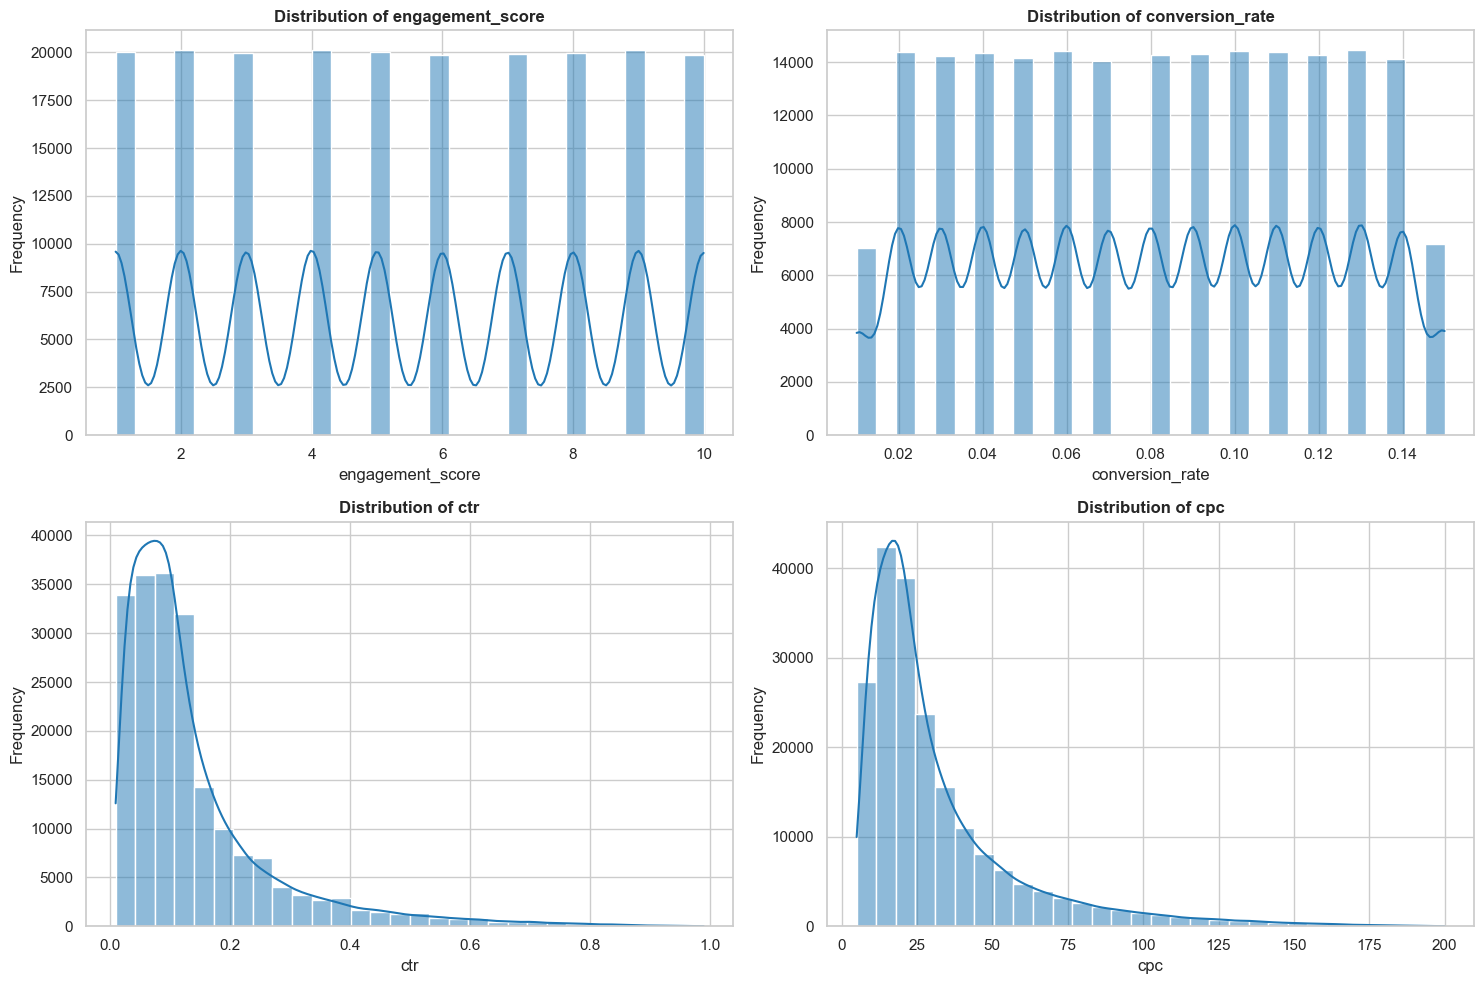

In [16]:
# Check distribution of numeric features to analyze
num_cols = ['engagement_score', 'conversion_rate', 'ctr', 'cpc']

fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(ml_df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12, weight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
        
    skew_val = ml_df[col].skew()
    direction = 'right-skewed' if skew_val > 0 else 'left-skewed' if skew_val < 0 else 'symmetric'
    print(f'{col.upper()} Skewness: {skew_val:.2f} ({direction})')

plt.tight_layout()
plt.show()

ROI Skewness: 1.80 (right-skewed)
PROFIT Skewness: 0.85 (right-skewed)


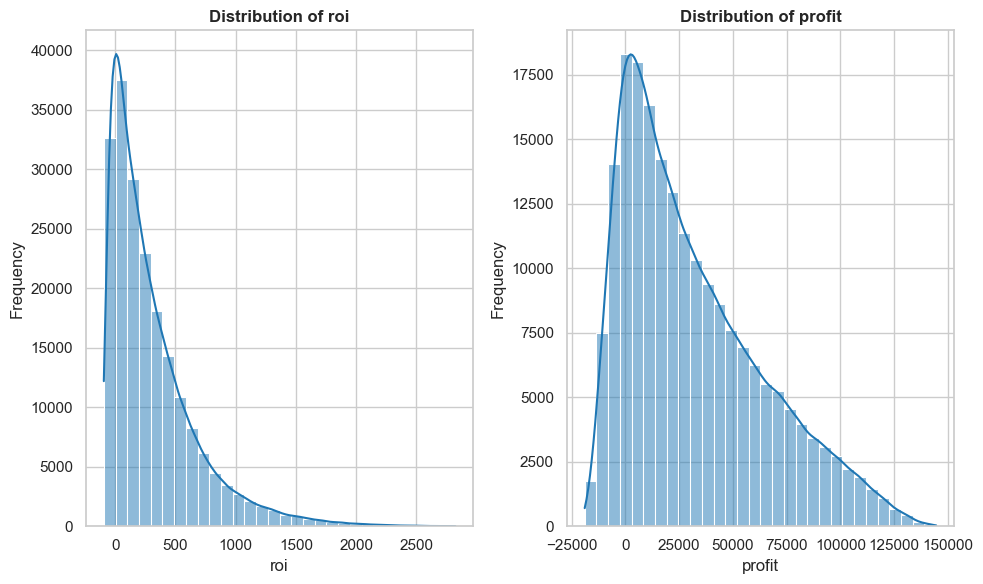

In [17]:
# Check distribution & skewness of target variables(ROI & Profit)
pred_cols = ['roi', 'profit']

fig, axes = plt.subplots(1, 2, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate (pred_cols):
    sns.histplot(ml_df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12, weight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    skew_val = ml_df[col].skew()
    direction = 'right-skewed' if skew_val > 0 else 'left-skewed' if skew_val < 0 else 'symmetric'
    print(f'{col.upper()} Skewness: {skew_val:.2f} ({direction})')


plt.tight_layout()
plt.show()

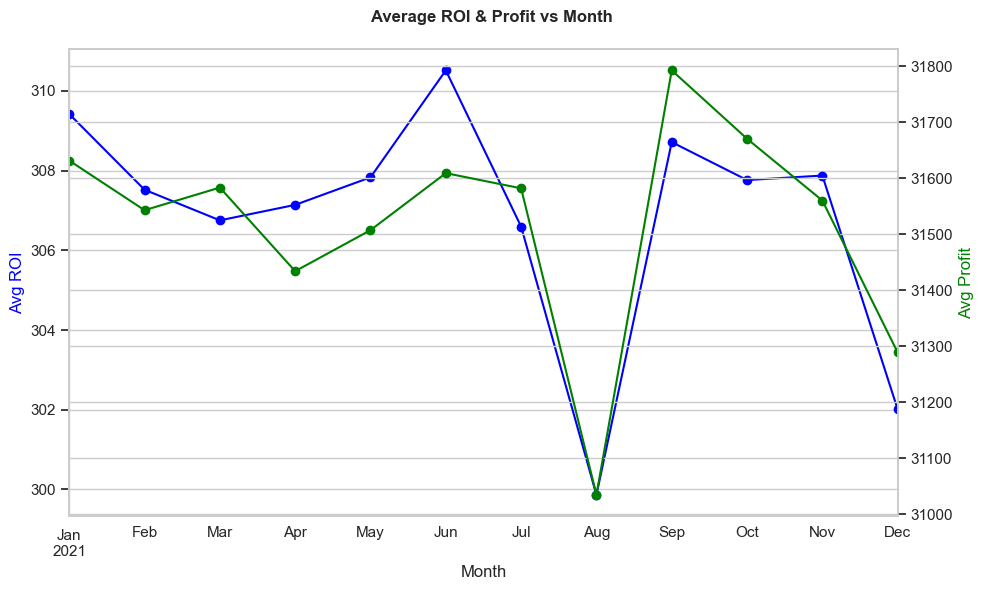

In [18]:
# Comparing the average ROI & Profit trends over time

fig, ax1 = plt.subplots(figsize=(10,6))
fig.suptitle('Average ROI & Profit vs Month', fontsize=12, weight='bold')

monthly_roi = ml_df.groupby('month')['roi'].mean()
monthly_profit = ml_df.groupby('month')['profit'].mean()

monthly_roi.plot(ax=ax1, color='blue', marker='o', label='ROI')
ax1.set_xlabel('Month')
ax1.set_ylabel('Avg ROI', color='blue')

ax2 = ax1.twinx()
monthly_profit.plot(ax=ax2, color='green', marker='o', label='Profit')
ax2.set_ylabel('Avg Profit', color='green')


plt.tight_layout()
plt.show()

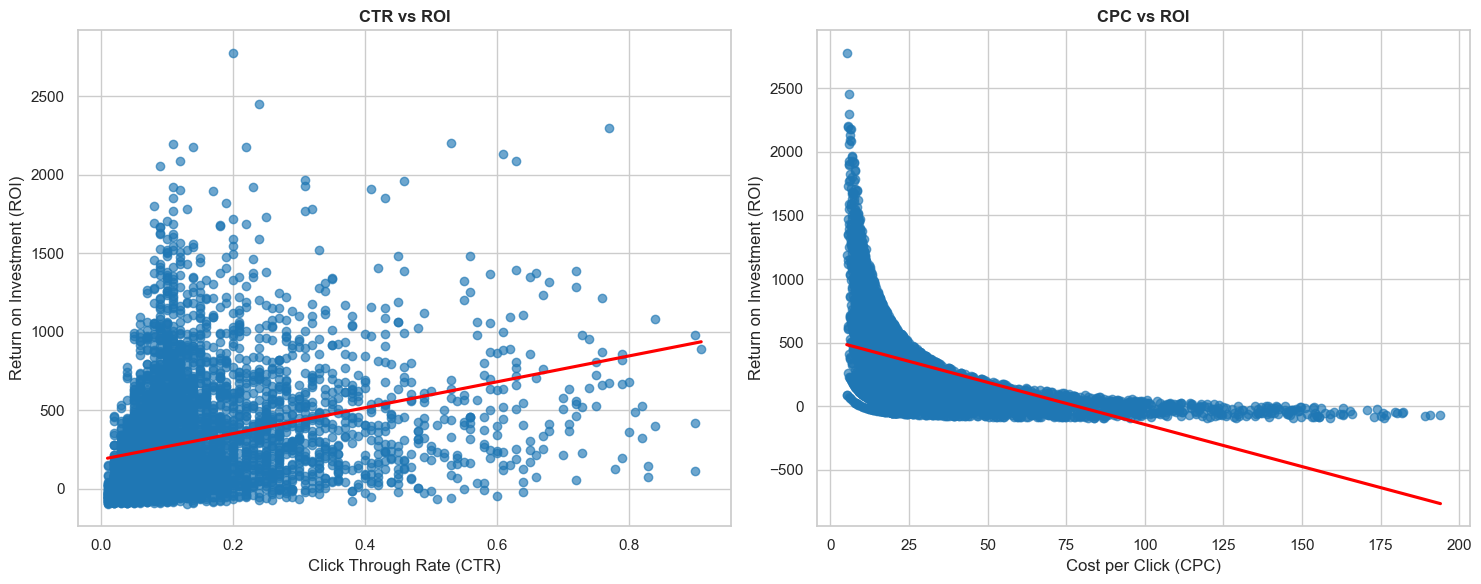

In [19]:
# Check relationship between Click Through Rate & Cost Per Click vs ROI
sample_df = ml_df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15,6))
axes = axes.flatten()

sns.regplot(x='ctr', y='roi', data=sample_df,ax=axes[0], scatter_kws={'alpha':0.65}, line_kws={'color':'red'}, ci=None)
axes[0].set_title('CTR vs ROI', fontsize=12, weight='bold')
axes[0].set_xlabel('Click Through Rate (CTR)')
axes[0].set_ylabel('Return on Investment (ROI)')

sns.regplot(x='cpc', y='roi', data=sample_df, ax=axes[1], scatter_kws={'alpha':0.65}, line_kws={'color':'red'}, ci=None)
axes[1].set_title('CPC vs ROI', fontsize=12, weight='bold')
axes[1].set_xlabel('Cost per Click (CPC)')
axes[1].set_ylabel('Return on Investment (ROI)')

plt.tight_layout()
plt.show()

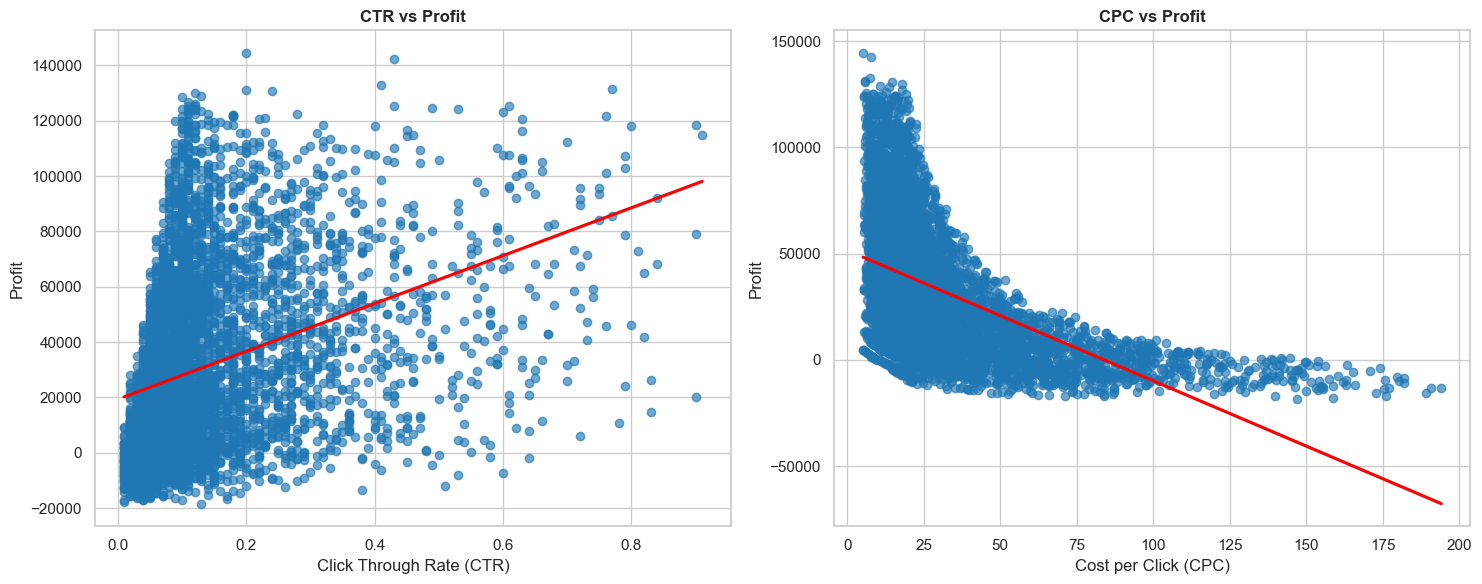

In [20]:
# Check relationship between Click Through Rate & Cost Per Click vs Profit
fig, axes = plt.subplots(1, 2, figsize=(15,6))
axes = axes.flatten()

sns.regplot(x='ctr', y='profit', data=sample_df,ax=axes[0], scatter_kws={'alpha':0.65}, line_kws={'color':'red'}, ci=None)
axes[0].set_title('CTR vs Profit', fontsize=12, weight='bold')
axes[0].set_xlabel('Click Through Rate (CTR)')
axes[0].set_ylabel('Profit')

sns.regplot(x='cpc', y='profit', data=sample_df, ax=axes[1], scatter_kws={'alpha':0.65}, line_kws={'color':'red'}, ci=None)
axes[1].set_title('CPC vs Profit', fontsize=12, weight='bold')
axes[1].set_xlabel('Cost per Click (CPC)')
axes[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

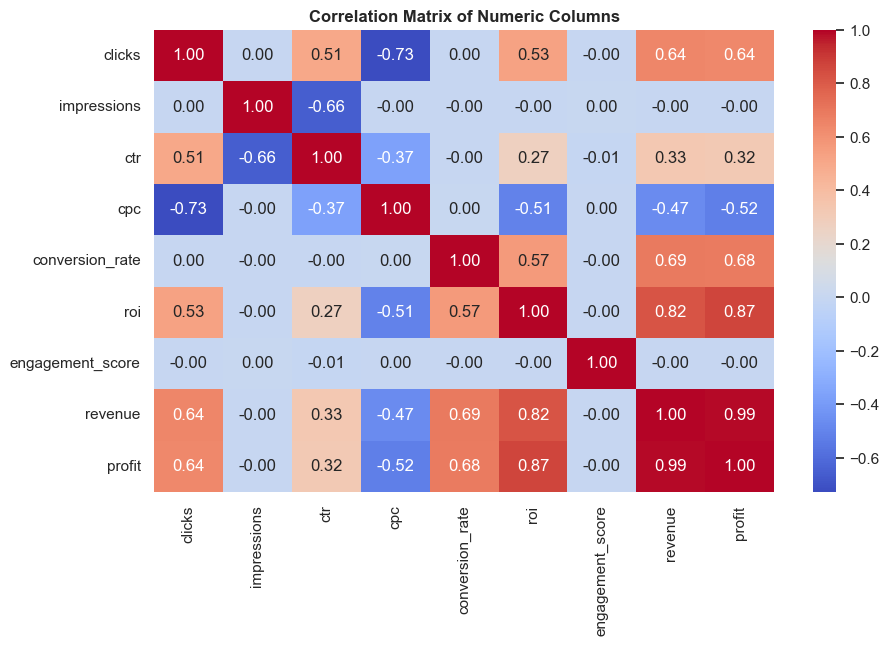

In [22]:
# Check for relationships between numerical variables(Correlation Analysis)
corr_cols = ['clicks', 'impressions', 'ctr', 'cpc', 'conversion_rate', 'roi', 'engagement_score', 'revenue', 'profit']
corr_matrix = ml_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix of Numeric Columns', fontsize=12, weight='bold')
plt.show()

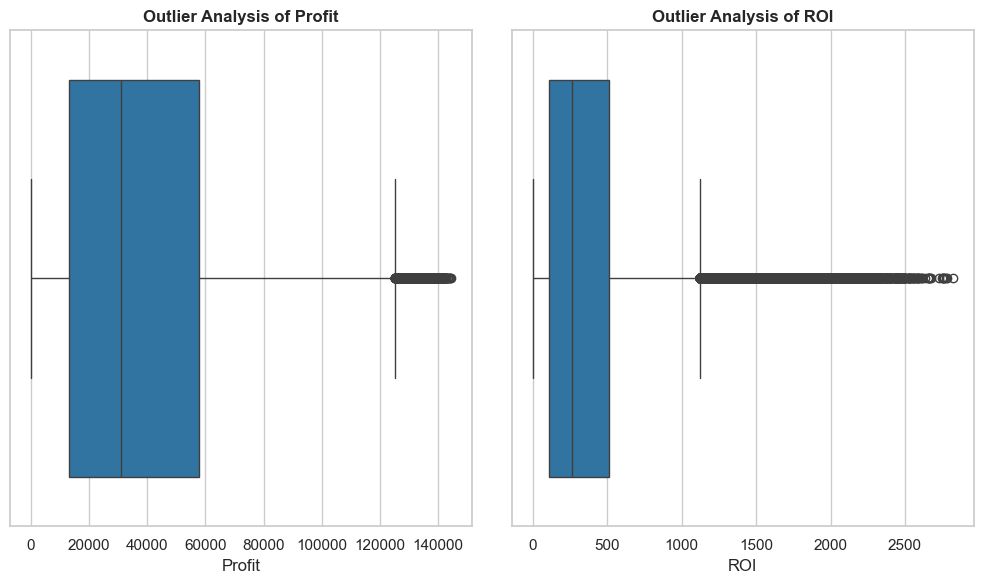

In [31]:
# Check for outliers on profit & ROI
fig, axes = plt.subplots(1, 2, figsize=(10,6))

sns.boxplot(x=ml_df['profit'], ax=axes[0])
axes[0].set_title('Outlier Analysis of Profit', fontsize=12, weight='bold')
axes[0].set_xlabel('Profit')

sns.boxplot(x=ml_df['roi'], ax=axes[1])
axes[1].set_title('Outlier Analysis of ROI', fontsize=12, weight='bold')
axes[1].set_xlabel('ROI')

plt.tight_layout()
plt.show()

## Feature Engineering & ML

In [23]:
# Filter negative profits & log transform
ml_df = ml_df[ml_df['profit'] > -1]

ml_df['profit_log'] = np.log1p(ml_df['profit'])

In [24]:
# Define numeric & categorical features
num_features = ['clicks','impressions','ctr','cpc','engagement_score']
cat_features = ['campaign_type', 'channel_used', 'customer_segment']

# Encoding categorical columns
df_encoded = pd.get_dummies(ml_df[cat_features], drop_first=True)

In [25]:
# Combine features & split data 
X = pd.concat([ml_df[num_features], df_encoded], axis=1)
y = ml_df['profit_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2,
                                                    random_state =42)

split ={'X_train':X_train,
        'X_test':X_test,
        'y_train':y_train,
        'y_test':y_test
       }
for i, col in split.items():
    print(f'{i}: {col.shape}')

X_train: (134707, 18)
X_test: (33677, 18)
y_train: (134707,)
y_test: (33677,)


In [26]:
# Build regression model
lr = LinearRegression()

In [27]:
# Fit th model on the training set
model = lr.fit(X_train, y_train)

# Use the model to predict the test set
y_pred = model.predict(X_test)

In [28]:
# Evaluate the model on the training set
mse = mean_squared_error(y_test, y_pred)
rsme = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Linear Regression Performance:')
print(f'RMSE:{rsme:.2f}')
print(f'R^2:{r2:.2f}')

Linear Regression Performance:
RMSE:0.99
R^2:0.31


                                 Feature  Coefficient
14              customer_segment_Foodies     0.018871
15    customer_segment_Health & Wellness     0.012938
17     customer_segment_Tech Enthusiasts     0.010050
16  customer_segment_Outdoor Adventurers     0.008536
6               campaign_type_Influencer     0.003117
10               channel_used_Google Ads     0.002227
0                                 clicks     0.001639
1                            impressions    -0.000001
4                       engagement_score    -0.000113
7                   campaign_type_Search    -0.000900
11                channel_used_Instagram    -0.004753
12                  channel_used_Website    -0.004904
8             campaign_type_Social Media    -0.006007
5                    campaign_type_Email    -0.006870
9                  channel_used_Facebook    -0.009669
13                  channel_used_YouTube    -0.014507
2                                    ctr    -0.015815
3                           

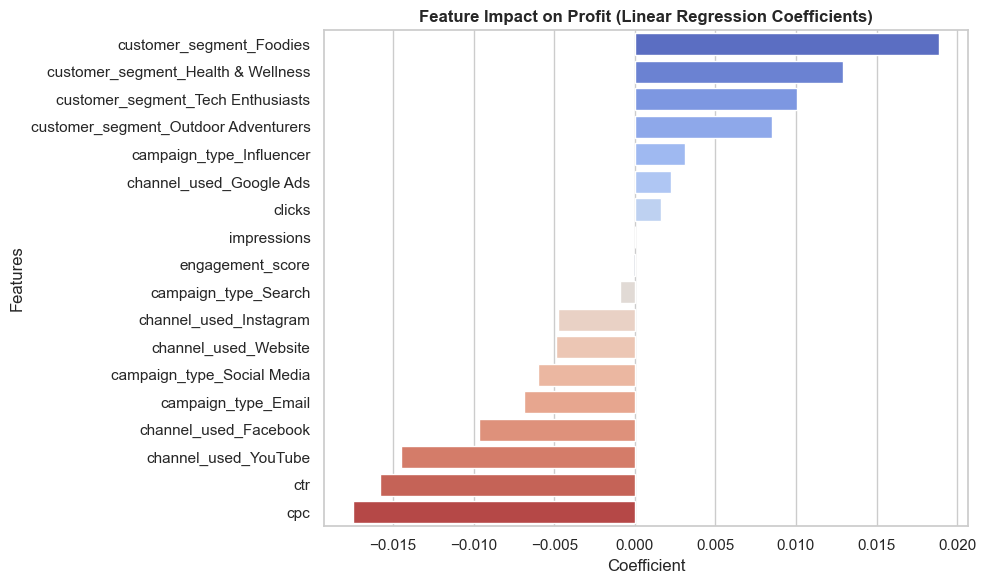

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

coef_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Coefficient':lr.coef_
}).sort_values(by='Coefficient', ascending=False)
print(coef_df)

sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', ax=ax)
ax.set_title('Feature Impact on Profit (Linear Regression Coefficients)', fontsize=12, weight='bold')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Features')

plt.tight_layout()
plt.show()

In [30]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

ml_df['cluster'] = clusters

# Inspect cluster characteristics
cluster_summary = ml_df.groupby('cluster')[['profit','roi','ctr','cpc','engagement_score']].mean()

max_profit = cluster_summary['profit'].max()
min_profit = cluster_summary['profit'].min()

performance_labels = []
for profit in cluster_summary['profit']:
    if profit == max_profit:
        performance_labels.append('Top-performing')
    elif profit == min_profit:
        performance_labels.append('Underperforming')
    else:
        performance_labels.append('Average-performing')

cluster_summary['performance'] = performance_labels

print(cluster_summary.round(2).to_string())

           profit     roi   ctr    cpc  engagement_score         performance
cluster                                                                     
0        40171.34  387.10  0.16  23.33              5.47  Average-performing
1        50224.93  492.61  0.20  16.49              5.51      Top-performing
2        18419.65  165.14  0.07  43.50              5.50     Underperforming


# Key Insights

- The distribution of key variables, including Profit and ROI, is positively skewed, suggesting that a small number of campaigns generate disproportionately high returns, while many perform at average or low levels.

- Time-based trends reveal that ROI and Profit fluctuate across months, indicating potential seasonality or shifts in campaign effectiveness over time.

- The analysis shows that Click-Through Rate (CTR) has a positive but weak relationship with both Profit and ROI. Campaigns with higher CTR tend to perform better, but the variability indicates that engagement alone is not a reliable predictor of success.

- Cost Per Click (CPC) demonstrates a strong and consistent negative relationship with Profit and ROI. As CPC increases, campaign profitability declines significantly, highlighting cost as a critical factor in performance.

- Correlation analysis reinforces that cost-related features (CPC) negatively impact profitability, while engagement-related features (CTR, engagement score) contribute positively but less consistently.

- Outlier analysis shows that a small number of campaigns generate exceptionally high Profit and ROI, contributing to the positive skewness in the data. These high-performing campaigns indicate that a few strategic executions drive a disproportionate share of overall business value. From a modeling perspective, the presence of outliers justifies the use of log transformation to stabilize variance and improve model reliability.

- **Regression analysis provides deeper insight into feature impact on profitability.**
  - CPC emerged as one of the strongest negative predictors of profit, confirming that rising acquisition costs significantly reduce returns.
  - CTR, while positively associated with profit, has a relatively small coefficient, indicating that higher engagement does not always translate directly into higher revenue.
  - Customer segments such as *Foodies* and *Health & Wellness* show positive contributions to profit, suggesting that targeting the right audience is more impactful than general engagement metrics.
  - Some marketing channels (e.g., Facebook, YouTube) show negative coefficients, indicating lower efficiency compared to other channels.
  - The model achieved an R² of 0.31, meaning a moderate portion of profit variability is explained, but external factors (e.g., campaign quality, timing, product demand) also play a significant role.

- Clustering analysis segments campaigns into top-performing, average-performing, and underperforming groups, showing clear differences in profitability, CTR, and CPC across campaigns.

# Conclusion

- Campaign performance is driven by both engagement and cost factors, with cost efficiency emerging as the most critical determinant of profitability.

- While higher CTR contributes positively to campaign outcomes, it does not guarantee success in the absence of controlled acquisition costs.

- Profitability is unevenly distributed, with a small subset of campaigns driving the majority of returns.

- Overall, the analysis confirms that low CPC and efficient conversion behavior are key characteristics of high-performing campaigns.

# Recommendations

- Prioritize reducing CPC through improved targeting, bidding strategies, and keyword optimization, as cost efficiency has the strongest impact on profitability.

- Use CTR as a supporting metric, focusing on attracting high-quality traffic rather than maximizing clicks alone.

- Identify and optimize underperforming campaigns, particularly those with high CPC and low ROI, by refining targeting strategies and reallocating budget.

- Scale high-performing campaigns that demonstrate low CPC and strong ROI to maximize returns.

- Leverage campaign segmentation to guide decision-making, allowing for more targeted optimization strategies across different performance groups.

- For future analysis, incorporate additional metrics like cost per acquisition (CPA) to enhance the evaluation of campaign effectiveness.